# Assignment 3 — Forward Propagation and Backpropagation

**Aim:** Implement forward propagation and backpropagation using TensorFlow/Keras. Analyze the effect of different learning rates and the number of epochs on model performance.

## Theory

**Forward Propagation:** The process where input data passes through the network layer by layer, each layer applying weights, biases, and activation functions, to produce an output prediction.

**Backpropagation:** After computing the loss (error) between the predicted and actual output, the gradients of the loss are calculated with respect to each weight using the chain rule. These gradients are then used to update the weights to minimize the loss.

In TensorFlow/Keras, `model.fit()` internally performs both forward propagation and backpropagation during training.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

## 2. Load and Explore the Dataset

We use the Breast Cancer dataset from sklearn. It has 30 features and 2 classes (malignant = 0, benign = 1), making it suitable for binary classification.

In [2]:
# Load the Breast Cancer dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.head())
print("\nDataset shape:", df.shape)
print("Target distribution:")
print(df['target'].value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

## 3. Data Preprocessing

In [3]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

In [4]:
# Normalize the features using StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 4. Train-Test Split

In [5]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)

Training set: (455, 30)
Testing set:  (114, 30)


## 5. Define the Neural Network

We define a function that creates a neural network model with a given learning rate. The model has two hidden layers (16 and 8 neurons with ReLU activation) and a sigmoid output layer for binary classification.

During `model.fit()`, TensorFlow/Keras internally performs:
- **Forward propagation** — computes predictions by passing inputs through each layer
- **Backpropagation** — computes gradients and updates weights to minimize the loss

In [6]:
# Function to create the neural network with a given learning rate
def create_model(learning_rate):

    model = Sequential([
        # Hidden layer 1: 16 neurons, ReLU activation
        Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
        # Hidden layer 2: 8 neurons, ReLU activation
        Dense(8, activation='relu'),
        # Output layer: 1 neuron, sigmoid for binary classification
        Dense(1, activation='sigmoid')
    ])

    # Adam optimizer with the specified learning rate
    optimizer = Adam(learning_rate=learning_rate)

    # Binary crossentropy loss for binary classification
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

## 6. Train with Different Learning Rates and Epochs

We train the model with 3 different learning rates (0.1, 0.01, 0.001) and 3 different epoch counts (10, 25, 50) to analyze their effect on performance.

In [7]:
# Define different learning rates and epoch counts to test
learning_rates = [0.1, 0.01, 0.001]
epochs_list = [10, 25, 50]

results = []

for lr in learning_rates:

    for ep in epochs_list:

        print(f"\nLearning Rate = {lr}, Epochs = {ep}")

        # Create a fresh model for each combination
        model = create_model(lr)

        # Train the model (forward prop + backprop happen internally)
        history = model.fit(
            X_train,
            y_train,
            epochs=ep,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        # Evaluate on test data
        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

        print(f"Test Accuracy = {accuracy:.4f}")

        results.append([lr, ep, accuracy])


Learning Rate = 0.1, Epochs = 10


c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy = 0.9649

Learning Rate = 0.1, Epochs = 25
Test Accuracy = 0.9737

Learning Rate = 0.1, Epochs = 50
Test Accuracy = 0.9561

Learning Rate = 0.01, Epochs = 10
Test Accuracy = 0.9737

Learning Rate = 0.01, Epochs = 25
Test Accuracy = 0.9825

Learning Rate = 0.01, Epochs = 50
Test Accuracy = 0.9825

Learning Rate = 0.001, Epochs = 10
Test Accuracy = 0.9825

Learning Rate = 0.001, Epochs = 25
Test Accuracy = 0.9737

Learning Rate = 0.001, Epochs = 50
Test Accuracy = 0.9825


## 7. Results

In [8]:
# Display results as a table
result_df = pd.DataFrame(
    results,
    columns=["Learning Rate", "Epochs", "Accuracy"]
)

print(result_df.to_string(index=False))

 Learning Rate  Epochs  Accuracy
         0.100      10  0.964912
         0.100      25  0.973684
         0.100      50  0.956140
         0.010      10  0.973684
         0.010      25  0.982456
         0.010      50  0.982456
         0.001      10  0.982456
         0.001      25  0.973684
         0.001      50  0.982456


## 8. Visualization — Effect of Learning Rate and Epochs

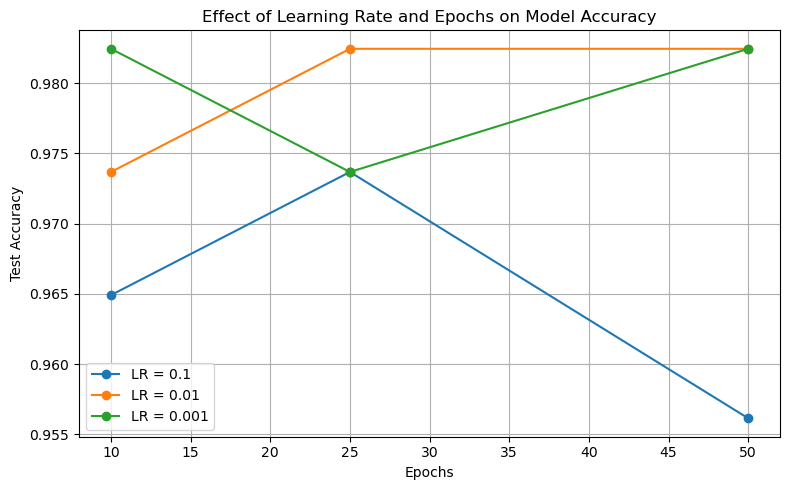

In [9]:
# Plot accuracy for each learning rate across different epoch counts
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    subset = result_df[result_df['Learning Rate'] == lr]
    plt.plot(subset['Epochs'], subset['Accuracy'], marker='o', label=f'LR = {lr}')

plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.title('Effect of Learning Rate and Epochs on Model Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion

In this assignment, we:
1. Implemented a neural network using TensorFlow/Keras, which internally performs forward propagation and backpropagation during training.
2. Analyzed the effect of different learning rates (0.1, 0.01, 0.001) and epoch counts (10, 25, 50) on model performance.

**Observations:**
- A very high learning rate (e.g., 0.1) may cause the model to overshoot the optimal weights, leading to unstable or lower accuracy.
- A moderate learning rate (e.g., 0.01) generally gives a good balance between convergence speed and final accuracy.
- A low learning rate (e.g., 0.001) converges slowly and may need more epochs to reach good accuracy.
- Increasing the number of epochs allows the model to train longer, which usually improves accuracy up to a point, after which overfitting may occur.